In [1]:
pip install gymnasium torch numpy

Note: you may need to restart the kernel to use updated packages.


In [14]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random

# Hyperparameters
GAMMA = 0.99
TAU = 0.005
ACTOR_LR = 1e-4
CRITIC_LR = 1e-3
BUFFER_SIZE = 100000
BATCH_SIZE = 64
EPISODES = 1000

**Replay buffer**

In [9]:
from collections import deque

class ReplayBuffer:

    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, transition):
        self.buffer.append(transition)

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            torch.FloatTensor(states),
            torch.FloatTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(next_states),
            torch.FloatTensor(dones)
        )

    def __len__(self):
        return len(self.buffer)

**Network**

In [11]:
# Actor Network
class Actor(nn.Module):

    def __init__(self, state_dim, action_dim, max_action):
        super().__init__()

        self.max_action = max_action

        self.fc1 = nn.Linear(state_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.out = nn.Linear(256, action_dim)

    def forward(self, state):

        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))

        action = torch.tanh(self.out(x)) * self.max_action

        return action


# Critic Network
class Critic(nn.Module):

    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.fc1 = nn.Linear(state_dim + action_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.out = nn.Linear(256, 1)

    def forward(self, state, action):

        x = torch.cat([state, action], dim=1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        q_value = self.out(x)

        return q_value



**Training loop**

In [15]:
def train():

    env = gym.make("Pendulum-v1")

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]

    max_action = float(env.action_space.high[0])

    actor = Actor(state_dim, action_dim, max_action)
    critic = Critic(state_dim, action_dim)

    target_actor = Actor(state_dim, action_dim, max_action)
    target_critic = Critic(state_dim, action_dim)

    target_actor.load_state_dict(actor.state_dict())
    target_critic.load_state_dict(critic.state_dict())

    actor_opt = optim.Adam(actor.parameters(), lr=ACTOR_LR)
    critic_opt = optim.Adam(critic.parameters(), lr=CRITIC_LR)

    buffer = ReplayBuffer(BUFFER_SIZE)

    rewards_per_episode = []

    for episode in range(EPISODES):

        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:

            state_t = torch.FloatTensor(state).unsqueeze(0)

            action = actor(state_t).cpu().detach().numpy()[0]

            # exploration noise
            action += np.random.normal(0, 0.1, size=action_dim)

            # clip action
            action = np.clip(action, -max_action, max_action)

            next_state, reward, terminated, truncated, _ = env.step(action)

            done = terminated or truncated

            buffer.push((state, action, reward, next_state, done))

            state = next_state
            total_reward += reward

            if len(buffer) < BATCH_SIZE:
                continue

            states, actions, rewards, next_states, dones = buffer.sample(BATCH_SIZE)

            with torch.no_grad():

                next_actions = target_actor(next_states)
                target_Q = target_critic(next_states, next_actions)

                y = rewards.unsqueeze(1) + GAMMA * (1 - dones.unsqueeze(1)) * target_Q

            current_Q = critic(states, actions)

            critic_loss = F.mse_loss(current_Q, y)

            critic_opt.zero_grad()
            critic_loss.backward()
            critic_opt.step()

            actor_loss = -critic(states, actor(states)).mean()

            actor_opt.zero_grad()
            actor_loss.backward()
            actor_opt.step()

            # soft update
            for target_param, param in zip(target_actor.parameters(), actor.parameters()):
                target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)

            for target_param, param in zip(target_critic.parameters(), critic.parameters()):
                target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)

        rewards_per_episode.append(total_reward)

        if episode % 100 == 0:
            print("Episode:", episode, "Reward:", total_reward)

    env.close()

    return rewards_per_episode

Episode: 0 Reward: -1666.1160252302652
Episode: 100 Reward: -646.8119531940426
Episode: 200 Reward: -260.38737079516613
Episode: 300 Reward: -123.72713308879132
Episode: 400 Reward: -124.50573849385464
Episode: 500 Reward: -123.22478806867942
Episode: 600 Reward: -121.78474809822089
Episode: 700 Reward: -229.10695159618678
Episode: 800 Reward: -127.55087714594053
Episode: 900 Reward: -118.56353075357163


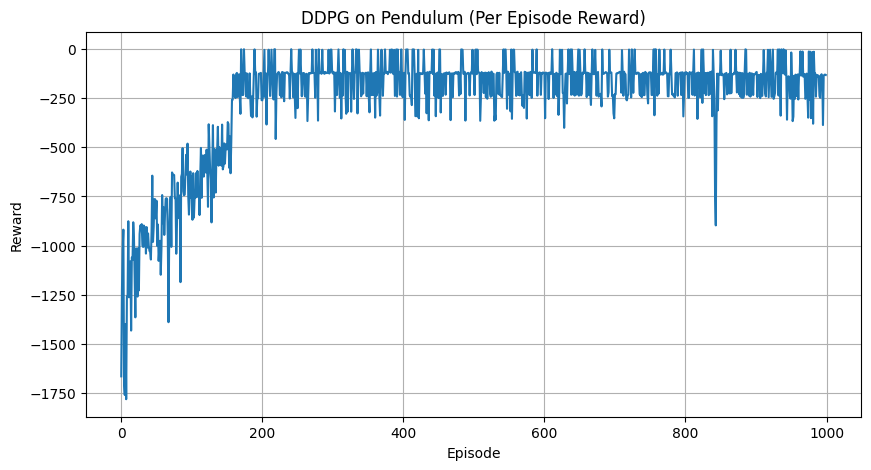

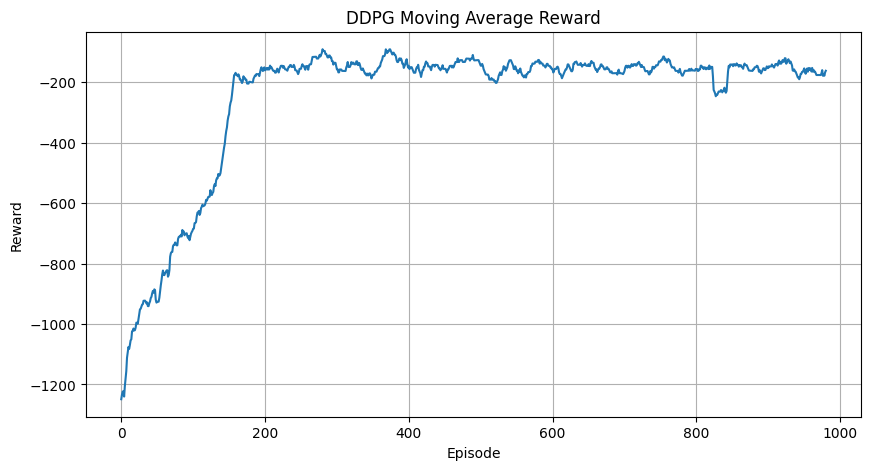

In [16]:
import matplotlib.pyplot as plt

rewards = train()

smoothed = np.convolve(rewards, np.ones(20)/20, mode='valid')

plt.figure(figsize=(10,5))
plt.plot(rewards)
plt.title("DDPG on Pendulum (Per Episode Reward)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(smoothed)
plt.title("DDPG Moving Average Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()
